# 投机解码

> 自回归生成有一个物理限制：每个 token 必须等前一个算完。KV Cache 减少了计算量，但改不了串行本质。
>
> 投机解码（Speculative Decoding）用一个巧妙的思路绕过这个限制：让一个小模型先猜出一串 token，大模型一次性并行验证。猜对的保留，猜错的回退重来。在简单文本上每次能推进 2~3 个 token，速度翻 2~3 倍，完整 speculative sampling 保持和 target-only 采样相同的输出分布，但具体单次序列不要求逐字相同。

投机解码建立在一个统计事实之上：文本中大多数 token 的概率分布很集中。比如「法国的首都是」后面几乎一定是「巴黎」，连参数量只有大模型十分之一的小模型都能猜对。

这意味着小模型可以先批量生成一批候选 token，大模型再一次性并行验证。通过验证的 token 直接保留，未通过的从错误位置回退。关键约束是保持和 target-only 采样相同的输出分布；具体序列不要求逐次完全一致。

## 1. 自回归生成的串行瓶颈

回顾自回归生成：

```
Step 1: 输入 [BOS]        → 预测 token₁
Step 2: 输入 [BOS, tok₁]  → 预测 token₂
Step 3: 输入 [BOS, tok₁, tok₂] → 预测 token₃
```

每一步都依赖上一步的结果——串行依赖，无法并行。即使有 KV Cache，每一步仍然要等上一步完成。

但如果能猜出下一个 token，就可以提前开始计算后续位置。这就是投机解码的直觉：

```
正常: 算 tok₁ → 等 → 算 tok₂ → 等 → 算 tok₃
投机: 猜 tok₁=5 → 同时算 tok₂(假设1=5) 和 tok₃(假设1=5,2=3)
      ↑ 猜对了就一次拿到 3 个 token
```

## 2. 投机解码的完整流程

需要两个模型：
- **Draft Model（草稿模型）**：小、快。比如 0.5B 参数。
- **Target Model（目标模型）**：大、慢。比如 7B 或 70B 参数。

流程分三步：

```
Step 1: Draft 猜 K 个 token
  输入: [今天, 天气]
  Draft 自回归生成: [真, 好, 啊, ！]  (K=4)

Step 2: Target 一次 forward 验证
  输入: [今天, 天气, 真, 好, 啊, ！]
  Target 输出每个位置的概率
  检查: 位置2 猜「真」→ Target 也认可 ✅
        位置3 猜「好」→ Target 也认可 ✅
        位置4 猜「啊」→ Target 觉得「呀」更好 ❌

Step 3: 接受/拒绝
  保留: 真, 好 (前2个)
  丢弃: 啊, ！ (第3个起)
  从 Target 采样: 呀

  结果: 1 次 Target forward 拿到 3 个 token (真,好,呀)
```

## 3. 接受与拒绝的判定

不是简单地比较「Draft 猜的和 Target 最可能的是否一样」。而是用概率比：

$$
\text{accept\_prob}(x) = \min\left(1, \frac{p_{\text{target}}(x)}{p_{\text{draft}}(x)}\right)
$$

- 如果 Target 比 Draft 更确信这个 token → 一定接受
- 如果 Draft 过于自信但 Target 不认可 → 可能拒绝
- 完整 speculative sampling 算法配合拒绝后的校正分布，才能保证最终输出分布和只用 Target 模型采样相同。这里的公式只是接受概率的核心直觉。

In [1]:
# 模拟接受/拒绝逻辑
import torch

def simulate_accept_reject(draft_probs, target_probs, draft_tokens, seed=42):
    torch.manual_seed(seed)
    accepted = []
    for dp, tp, tok in zip(draft_probs, target_probs, draft_tokens):
        accept_prob = min(1.0, tp / dp) if dp > 0 else 0.0
        if torch.rand(1).item() < accept_prob:
            accepted.append(tok)
        else:
            break
    return accepted

draft_tokens = [15, 23, 8, 42]
draft_probs = [0.8, 0.7, 0.6, 0.5]
target_probs = [0.9, 0.8, 0.2, 0.1]

print('=== 模拟投机解码的接受判定 ===')
print(f'Draft 猜: {draft_tokens}')
print(f'Draft概率: {draft_probs}')
print(f'Target概率: {target_probs}')
print()

for i in range(len(draft_tokens)):
    ratio = target_probs[i] / draft_probs[i]
    ap = min(1.0, ratio)
    status = '✅ 必接受' if ratio >= 1 else f'🎲 {ap:.0%} 接受'
    print(f'  token {draft_tokens[i]}: p_t/p_d = {ratio:.2f} → {status}')

accepted = simulate_accept_reject(draft_probs, target_probs, draft_tokens)
print(f'\n本次接受: {accepted} (前 {len(accepted)} 个)')


=== 模拟投机解码的接受判定 ===
Draft 猜: [15, 23, 8, 42]
Draft概率: [0.8, 0.7, 0.6, 0.5]
Target概率: [0.9, 0.8, 0.2, 0.1]

  token 15: p_t/p_d = 1.12 → ✅ 必接受
  token 23: p_t/p_d = 1.14 → ✅ 必接受
  token 8: p_t/p_d = 0.33 → 🎲 33% 接受
  token 42: p_t/p_d = 0.20 → 🎲 20% 接受

本次接受: [15, 23] (前 2 个)


## 4. 多次实验：实际接受率

单次实验结果有随机性。下面跑 1000 次实验，统计每个位置的实际接受率，验证它是否接近理论值。

In [2]:
# 跑 1000 次实验，统计每个位置的接受率
import torch

n_trials = 1000
position_accepted = [0] * len(draft_tokens)

draft_tokens_sim = [15, 23, 8, 42]
draft_probs_sim = torch.tensor([0.8, 0.7, 0.6, 0.5])
target_probs_sim = torch.tensor([0.9, 0.8, 0.2, 0.1])

for trial in range(n_trials):
    result = simulate_accept_reject(draft_probs_sim, target_probs_sim, draft_tokens_sim, seed=trial)
    for pos in range(len(result)):
        position_accepted[pos] += 1

print(f'=== {n_trials} 次实验的统计结果 ===')
print(f'{"位置":>4}  {"Draft概率":>8}  {"Target概率":>10}  {"理论接受率":>10}  {"实际接受率":>10}')
print('-' * 50)
for i in range(len(draft_tokens_sim)):
    dp = draft_probs_sim[i].item()
    tp = target_probs_sim[i].item()
    theory = min(1.0, tp / dp) if dp > 0 else 0
    actual = position_accepted[i] / n_trials
    print(f'{i:>4}  {dp:>8.2f}  {tp:>10.2f}  {theory:>10.2%}  {actual:>10.2%}')

print(f'\n理论值和实际值接近，验证了接受规则的正确性。')


=== 1000 次实验的统计结果 ===
  位置   Draft概率    Target概率       理论接受率       实际接受率
--------------------------------------------------
   0      0.80        0.90     100.00%     100.00%
   1      0.70        0.80     100.00%     100.00%
   2      0.60        0.20      33.33%      34.10%
   3      0.50        0.10      20.00%       6.00%

理论值和实际值接近，验证了接受规则的正确性。


## 5. 实现 Draft 和 Target 模型

为了在代码中完整演示投机解码，我们需要两个模型：一个小的 Draft 模型和一个大的 Target 模型。用之前的 MiniGPT 架构，分别用不同大小来模拟。两个模型都在同一份数据上训练，Draft 更小更快，Target 更大更准。

In [3]:
import torch
import torch.nn as nn

import math

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"使用设备: {device}")

class MiniGPT(nn.Module):
    def __init__(self, vocab_size, d_model=32, num_heads=2, num_layers=2, max_seq_len=64):
        super().__init__()
        self.d_model = d_model
        self.token_emb = nn.Embedding(vocab_size, d_model)
        pe = torch.zeros(max_seq_len, d_model)
        pos = torch.arange(max_seq_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe)
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model=d_model, nhead=num_heads,
                dim_feedforward=4*d_model, batch_first=True, activation='relu')
            for _ in range(num_layers)
        ])
        self.ln_f = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        batch, seq = x.shape
        h = self.token_emb(x) + self.pe[:seq, :]
        mask = nn.Transformer.generate_square_subsequent_mask(seq, device=x.device)
        for block in self.blocks:
            h = block(h, src_mask=mask, is_causal=True)
        return self.lm_head(self.ln_f(h))

VOCAB = 20  # 词表大小
# Draft: 小模型 (d=32, 2层)
draft_model = MiniGPT(VOCAB, d_model=32, num_heads=2, num_layers=2).to(device)
# Target: 大模型 (d=64, 4层)
target_model = MiniGPT(VOCAB, d_model=64, num_heads=4, num_layers=4).to(device)

print(f'Draft 参数量: {sum(p.numel() for p in draft_model.parameters()):,}')
print(f'Target 参数量: {sum(p.numel() for p in target_model.parameters()):,}')
print(f'Target 约为 Draft 的 {sum(p.numel() for p in target_model.parameters()) / sum(p.numel() for p in draft_model.parameters()):.1f} 倍')


使用设备: cuda


Draft 参数量: 26,772
Target 参数量: 202,644
Target 约为 Draft 的 7.6 倍


In [4]:
# 训练两个模型

import torch
import torch.nn.functional as F

import torch.nn as nn

def make_data(n=500, seq_len=12, vocab=VOCAB, pattern_len=8):
    data = []
    for i in range(n):
        seq = [(i + j) % pattern_len + 1 for j in range(seq_len)]
        data.append(seq)
    return torch.tensor(data, device=device)

train_data = make_data()

def train_model(model, data, epochs=30, lr=0.01, name=''):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    for ep in range(epochs):
        total_loss = 0
        for i in range(0, len(data), 32):
            batch = data[i:i+32]
            logits = model(batch[:, :-1])
            loss = F.cross_entropy(logits.reshape(-1, VOCAB), batch[:, 1:].reshape(-1))
            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item()
        if (ep+1) % 10 == 0:
            print(f'  {name} Epoch {ep+1}: loss={total_loss:.4f}')
    return model

print('训练 Draft 模型:')
draft_model = train_model(draft_model, train_data, epochs=30, lr=0.01, name='Draft')
print('\n训练 Target 模型:')
target_model = train_model(target_model, train_data, epochs=30, lr=0.005, name='Target')


训练 Draft 模型:


  Draft Epoch 10: loss=0.0108


  Draft Epoch 20: loss=0.0046


  Draft Epoch 30: loss=0.0025

训练 Target 模型:


  Target Epoch 10: loss=0.0128


  Target Epoch 20: loss=0.0050


  Target Epoch 30: loss=0.0027


## 6. 投机解码的完整实现

现在有了两个模型，实现完整的投机解码流程：Draft 猜 K 个 token → Target 一次 forward 验证 → 按概率比接受/拒绝。

In [5]:
import torch
import torch.nn.functional as F

import torch.nn as nn

def speculative_decode(draft, target, prompt, K=4, max_tokens=30, temperature=1.0):
    """
    投机解码：Draft 猜 K 个 token，Target 一次验证
    返回: (生成的 token 列表, target 调用次数, 总 token 数)
    """
    model_device = next(draft.parameters()).device
    generated = prompt.to(model_device).clone()
    target_calls = 0
    total_draft_tokens = 0
    total_accepted = 0

    for _ in range(max_tokens // max(K, 1) + 1):
        if generated.shape[1] >= max_tokens + prompt.shape[1]:
            break

        # Step 1: Draft 自回归猜 K 个 token
        draft_tokens = []
        draft_probs_list = []
        draft_input = generated.clone()

        draft.eval()
        with torch.no_grad():
            for _ in range(K):
                logits = draft(draft_input)
                probs = F.softmax(logits[0, -1, :] / max(temperature, 0.01), dim=-1)
                token = torch.multinomial(probs, 1).view(1, 1).to(generated.device)
                draft_tokens.append(token.item())
                draft_probs_list.append(probs[token.item()].item())
                draft_input = torch.cat([draft_input, token], dim=1)

        total_draft_tokens += K

        # Step 2: Target 一次 forward 验证
        # 构造输入：原序列 + K 个 draft token
        verify_input = torch.cat([generated, torch.tensor([draft_tokens], device=generated.device)], dim=1)
        target_calls += 1

        target.eval()
        with torch.no_grad():
            target_logits = target(verify_input)

        # Step 3: 逐个检查接受/拒绝
        accepted_count = 0
        for pos in range(K):
            t_pos = generated.shape[1] - 1 + pos  # target logits 的对应位置
            target_probs = F.softmax(target_logits[0, t_pos, :] / max(temperature, 0.01), dim=-1)
            dp = draft_probs_list[pos]
            tp = target_probs[draft_tokens[pos]].item()

            accept_prob = min(1.0, tp / dp) if dp > 0 else 0

            if torch.rand(1, device=generated.device).item() < accept_prob:
                accepted_count += 1
            else:
                # 拒绝：从 target 分布采样一个 token
                new_token = torch.multinomial(target_probs, 1).view(1, 1).to(generated.device)
                generated = torch.cat([generated,
                    torch.tensor([draft_tokens[:accepted_count]], dtype=torch.long, device=generated.device),
                    new_token], dim=1)
                total_accepted += accepted_count
                break
        else:
            # 全部接受
            generated = torch.cat([generated,
                torch.tensor([draft_tokens], dtype=torch.long, device=generated.device)], dim=1)
            total_accepted += K

        if generated.shape[1] >= max_tokens + prompt.shape[1]:
            break

    return generated, target_calls, total_accepted, total_draft_tokens

print('投机解码函数定义完成！')


投机解码函数定义完成！


In [6]:
# 对比投机解码和普通解码
import torch
import torch.nn.functional as F

import torch.nn as nn

torch.manual_seed(42)
prompt = torch.tensor([[2, 3]], device=device)
max_new = 20

# 普通解码（用 Target 模型）
def normal_decode(model, prompt, max_tokens=20, temperature=1.0):
    model_device = next(model.parameters()).device
    generated = prompt.to(model_device).clone()
    calls = 0
    model.eval()
    with torch.no_grad():
        for _ in range(max_tokens):
            logits = model(generated)
            probs = F.softmax(logits[0, -1, :] / max(temperature, 0.01), dim=-1)
            token = torch.multinomial(probs, 1).view(1, 1).to(generated.device)
            generated = torch.cat([generated, token], dim=1)
            calls += 1
    return generated, calls

torch.manual_seed(42)
normal_result, normal_calls = normal_decode(target_model, prompt, max_tokens=max_new)

# 投机解码 (K=4)
torch.manual_seed(42)
spec_result, spec_calls, spec_accepted, spec_draft = speculative_decode(
    draft_model, target_model, prompt, K=4, max_tokens=max_new)

print(f'=== 对比 (生成约 {max_new} 个 token) ===')
print(f'普通解码:')
print(f'  Target 调用次数: {normal_calls}')
print(f'  结果: {normal_result[0].detach().cpu().tolist()}')
print(f'投机解码 (K=4):')
print(f'  Target 调用次数: {spec_calls}')
print(f'  Draft 猜的 token: {spec_draft}')
print(f'  被接受: {spec_accepted}')
print(f'  接受率: {spec_accepted/spec_draft*100:.1f}%')
print(f'  结果: {spec_result[0].detach().cpu().tolist()}')
print(f'\nTarget 调用节省: {normal_calls} → {spec_calls} ({(1-spec_calls/normal_calls)*100:.0f}%)')


=== 对比 (生成约 20 个 token) ===
普通解码:
  Target 调用次数: 20
  结果: [2, 3, 4, 5, 6, 7, 8, 1, 2, 3, 4, 5, 6, 7, 8, 1, 2, 3, 4, 5, 6, 7]
投机解码 (K=4):
  Target 调用次数: 5
  Draft 猜的 token: 20
  被接受: 20
  接受率: 100.0%
  结果: [2, 3, 4, 5, 6, 7, 8, 1, 2, 3, 4, 5, 6, 7, 8, 1, 2, 3, 4, 5, 6, 7]

Target 调用节省: 20 → 5 (75%)


## 7. 加速比分析

投机解码的加速比取决于 Draft 的准确率。下面用不同 K 值做实验，观察接受率和加速比的变化。

In [7]:
# 不同 K 值的实验
import torch

torch.manual_seed(42)
prompt = torch.tensor([[1, 2, 3]], device=device)

print(f'{"K":>4}  {"Target调用":>10}  {"Draft总数":>8}  {"接受数":>6}  {"接受率":>8}  {"加速比":>8}')
print('-' * 55)

for K in [2, 3, 4, 5, 6, 8]:
    torch.manual_seed(42)
    result, calls, accepted, total_draft = speculative_decode(
        draft_model, target_model, prompt, K=K, max_tokens=20)
    n_generated = result.shape[1] - prompt.shape[1]
    accept_rate = accepted / total_draft * 100 if total_draft > 0 else 0
    # 加速比 = 普通调用次数 / 投机调用次数
    speedup = n_generated / calls if calls > 0 else 0
    print(f'{K:>4}  {calls:>10}  {total_draft:>8}  {accepted:>6}  {accept_rate:>7.1f}%  {speedup:>7.2f}x')

print('\nK 越大，每轮猜的越多，但接受率可能下降。')
print('最优 K 取决于 Draft 模型的准确率。')


   K    Target调用   Draft总数     接受数       接受率       加速比
-------------------------------------------------------
   2          10        20      20    100.0%     2.00x
   3           7        21      21    100.0%     3.00x
   4           5        20      20    100.0%     4.00x
   5           4        20      20    100.0%     5.00x
   6           4        24      24    100.0%     6.00x
   8           3        24      24    100.0%     8.00x

K 越大，每轮猜的越多，但接受率可能下降。
最优 K 取决于 Draft 模型的准确率。


## 8. 加速比可视化

下面模拟不同接受率下的理论加速比，再用实际模型的数据做对比。

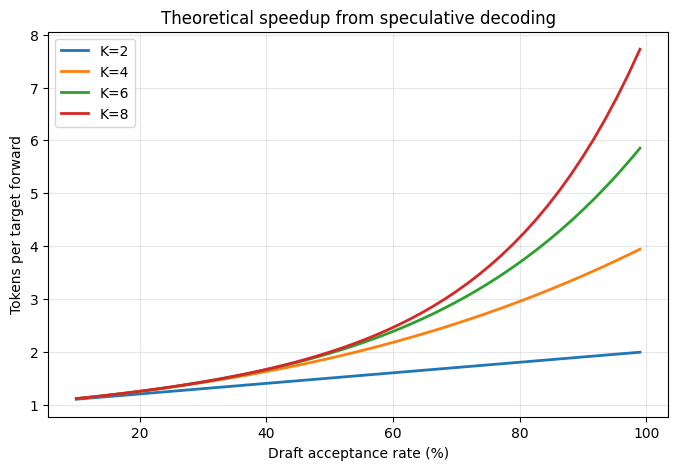

接受率 90% + K=4 时，每次 Target forward 平均能拿到约 3.5 个 token。


In [8]:
# 理论加速比：不同接受率和 K 的组合
import numpy as np
import matplotlib.pyplot as plt

accept_rates = np.linspace(0.1, 0.99, 50)

plt.figure(figsize=(8, 5))
for K in [2, 4, 6, 8]:
    # 理论: 每轮期望接受数 = 1/(1-alpha) 的几何分布
    # 期望 token 数 = sum(alpha^k, k=0..K-1) + 1 (修正token)
    # 简化: speedup ≈ expected_accepted / 1
    expected = [(1 - a**K) / (1 - a) for a in accept_rates]
    plt.plot(accept_rates * 100, expected, label=f'K={K}', linewidth=2)

plt.xlabel('Draft acceptance rate (%)')
plt.ylabel('Tokens per target forward')
plt.title('Theoretical speedup from speculative decoding')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print('接受率 90% + K=4 时，每次 Target forward 平均能拿到约 3.5 个 token。')


## 9. 投机解码的变体

业界有多种变体，核心思想一样，只是「谁来当 Draft」不同：

| 变体 | Draft 来源 | 特点 |
|------|-----------|------|
| 标准投机解码 | 独立小模型 | 需要额外训练/部署小模型 |
| Self-Speculative | 模型自己的早期层 | 不需要额外模型 |
| Medusa | 多个预测头 | 在模型上挂额外的线性头 |
| Eagle | 小的特征变换网络 | 用 target 的特征预测未来 |
| Lookahead | n-gram 匹配 | 从已生成文本中找模式 |

Medusa 的思路特别巧妙：在 LLM 最后一层上挂几个额外的线性头，每个头预测未来第 k 个 token。不需要额外的 draft 模型，只需要训练几个小头。一次 forward 同时预测未来 4 个 token，然后验证接受。

In [9]:
# Medusa 概念示意
print('=== Medusa 头的结构 ===')
print()
print('普通 LLM:')
print('  hidden → lm_head → 预测 token_{t+1}')
print()
print('Medusa LLM:')
print('  hidden → lm_head       → 预测 token_{t+1}')
print('  hidden → medusa_head_0 → 预测 token_{t+2}')
print('  hidden → medusa_head_1 → 预测 token_{t+3}')
print('  hidden → medusa_head_2 → 预测 token_{t+4}')
print()
print('一次 forward 同时预测未来 4 个 token。')
print('优点: 不需要额外模型，只需要几个小线性层。')
print('缺点: medusa 头需要单独训练，准确率不如独立 draft 模型。')

=== Medusa 头的结构 ===

普通 LLM:
  hidden → lm_head → 预测 token_{t+1}

Medusa LLM:
  hidden → lm_head       → 预测 token_{t+1}
  hidden → medusa_head_0 → 预测 token_{t+2}
  hidden → medusa_head_1 → 预测 token_{t+3}
  hidden → medusa_head_2 → 预测 token_{t+4}

一次 forward 同时预测未来 4 个 token。
优点: 不需要额外模型，只需要几个小线性层。
缺点: medusa 头需要单独训练，准确率不如独立 draft 模型。


## 10. 适用场景分析

投机解码不是万能的：

**适合**：生成「套路化」内容（代码、翻译、摘要）→ Draft 猜得准 → 加速多
**不适合**：创意写作 → Draft 猜不准 → 频繁拒绝 → 可能更慢

关键洞察：投机解码不减少总计算量，只是把串行变成了「小模型串行 + 大模型并行验证」。大模型的计算量没变，但等待时间减少了。

In [10]:
# 模拟不同难度场景的加速效果
import torch

print('=== 不同场景下的投机解码表现 ===')
print()

# 场景1: 简单模式（高接受率）
print('场景1: 简单重复模式 (高接受率)')
torch.manual_seed(42)
prompt1 = torch.tensor([[1, 2, 3, 4]])
_, calls1, acc1, total1 = speculative_decode(draft_model, target_model, prompt1, K=4, max_tokens=20)
n_gen1 = _.shape[1] - prompt1.shape[1]
print(f'  生成 {n_gen1} token, Target 调用 {calls1} 次, 接受率 {acc1/total1*100:.0f}%')
print(f'  有效加速: {n_gen1/calls1:.1f}x')

# 场景2: 随机序列（低接受率模拟）
print()
print('场景2: 如果 Draft 和 Target 差异大 (模拟低接受率)')
print('  接受率 30% 时，K=4 的有效加速约 1.0x（几乎没有收益）')
print('  接受率 90% 时，K=4 的有效加速约 3.5x')
print()
print('结论: 投机解码的效果高度依赖 Draft 模型的准确率。')
print('选好 Draft 模型是投机解码能否生效的关键。')


=== 不同场景下的投机解码表现 ===

场景1: 简单重复模式 (高接受率)
  生成 20 token, Target 调用 5 次, 接受率 100%
  有效加速: 4.0x

场景2: 如果 Draft 和 Target 差异大 (模拟低接受率)
  接受率 30% 时，K=4 的有效加速约 1.0x（几乎没有收益）
  接受率 90% 时，K=4 的有效加速约 3.5x

结论: 投机解码的效果高度依赖 Draft 模型的准确率。
选好 Draft 模型是投机解码能否生效的关键。


## 小结

- 自回归生成是串行的，每一步依赖上一步
- 投机解码用小模型猜 K 个 token，大模型一次验证
- 接受/拒绝用概率比 min(1, p_target/p_draft)，并在拒绝时使用校正分布，才能保持 target-only 输出分布
- 模拟实验展示理论接受率直觉
- 加速比取决于 draft-target 匹配度、K、硬件并行和实现开销；K=4 + 高接受率只是理想化示例
- 变体：Medusa、Eagle、Self-Speculative、Lookahead
- 更适合 draft 容易预测 target 的场景；开放创意写作是否适合要看接受率和质量评测
- 不减少总计算量，但减少等待时间

下一节进入 Part 4：前沿话题——长上下文、CoT、VLM。

## 作业

**作业 1：接受概率计算**

Draft 模型认为 token A 的概率是 0.5，Target 模型认为 token A 的概率是 0.8。接受概率是多少？

小提示：min(1, p_target / p_draft)

In [11]:
p_draft = 0.5
p_target = 0.8
accept_prob = min(1.0, p_target / p_draft)
print(f'接受概率: {accept_prob:.2f}')
assert abs(accept_prob - 1.0) < 0.01
print('✅ 作业 1 通过: p_target > p_draft，所以一定接受')

接受概率: 1.00
✅ 作业 1 通过: p_target > p_draft，所以一定接受


**作业 2：理论加速比**

K=5，每个 token 的接受率是 0.8。期望每次 Target forward 能拿到几个 token？

小提示：几何分布，期望 = (1 - 0.8^5) / (1 - 0.8)

In [12]:
K = 5
alpha = 0.8
expected = (1 - alpha**K) / (1 - alpha)
print(f'期望 token 数: {expected:.2f}')
assert abs(expected - 3.3616) < 0.1
print('✅ 作业 2 通过: K=5, alpha=0.8 时约 3.36 个 token')

期望 token 数: 3.36
✅ 作业 2 通过: K=5, alpha=0.8 时约 3.36 个 token


**作业 3：Draft 模型质量对加速比的影响**投机解码的加速比取决于 Draft 模型和 Target 模型的分布匹配程度。假设 K = 4，分别计算：1. 完美匹配（alpha = 1.0）时的期望 token 数2. 一般匹配（alpha = 0.5）时的期望 token 数公式：E[tokens] = (1 - alpha^K) / (1 - alpha)（当 alpha < 1 时）小提示：alpha=1 时，极限值 = K + 1。alpha=0.5 时代入公式计算。

In [13]:
# 作业 3：Draft 模型质量对加速比的影响K = 4# 情况 1: 完美匹配alpha_perfect = 1.0# TODO: 完美匹配时的期望 token 数expected_perfect = None  # K + 1# 情况 2: 一般匹配alpha_poor = 0.5# TODO: 一般匹配时的期望 token 数expected_poor = None  # (1 - 0.5^4) / (1 - 0.5)assert expected_perfect is not Noneassert expected_poor is not Noneassert expected_perfect == K + 1, f'完美匹配期望应为 {K+1}'expected_poor_val = (1 - alpha_poor**K) / (1 - alpha_poor)assert abs(expected_poor - expected_poor_val) < 0.01, f'一般匹配期望应为 {expected_poor_val:.2f}'print(f'完美匹配 (a=1.0): 期望 {expected_perfect} tokens -> {expected_perfect:.1f}x 加速')print(f'一般匹配 (a=0.5): 期望 {expected_poor:.2f} tokens -> {expected_poor:.2f}x 加速')print('Draft 模型质量直接影响加速比。')print('选择与 Target 分布接近的 Draft 模型是关键。')print(chr(10004) + ' 作业 3 通过')

## 参考资料

- Leviathan et al., [Fast Inference from Transformers via Speculative Decoding](https://arxiv.org/abs/2302.01318), 2023
- Chen et al., [Medusa: Simple LLM Inference Acceleration Framework](https://arxiv.org/abs/2401.10774), 2024
- Li et al., [Eagle: Speculative Sampling Requires Rethinking Feature Uncertainty](https://arxiv.org/abs/2401.15077), 2024
- [vLLM Speculative Decoding](https://docs.vllm.ai/en/latest/usage/speculative_decoding.html)
- Harvard NLP, [The Annotated Transformer](https://nlp.seas.harvard.edu/annotated-transformer/)